<a href="https://colab.research.google.com/github/reddy-nithin/Iterative-Transformers/blob/main/notebooks/colab_walkthrough.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Iterative ViT-Tiny: Reusing a Single Transformer Block

## Objective

A pretrained ViT-Tiny stacks 12 transformer blocks, each with its own weights. This notebook asks how much accuracy is lost
when the 12 blocks are replaced by **one** pretrained block applied 12 times with shared weights. Sharing removes about 88% of
the parameters.

## Models compared

All models are fine-tuned on CIFAR-100 with an identical recipe.

| Name | Description |
|---|---|
| `baseline` | Standard pretrained ViT-Tiny with 12 distinct blocks |
| `iterative_b0`, `iterative_b6` | Block 0 (or 6) repeated 12 times in an `nn.Sequential` |
| `looped_b0`, `looped_b6` | Block 0 (or 6) copied from its state dict and applied 12 times by an explicit `for` loop (Section 11) |

## Recipe

| Setting | Value |
|---|---|
| Dataset | CIFAR-100, 50,000 train / 10,000 test images, resized to 224 x 224 |
| Epochs | 10 (1 warmup epoch, then cosine decay) |
| Optimizer | AdamW, learning rate 1e-4, weight decay 0.05 |
| Loss | Cross-entropy, label smoothing 0.1 |
| Batch size / seed | 128 / 0 |
| Precision | Mixed precision (AMP) on a GPU |

## Notes on execution

- Run on a Colab GPU runtime (*Runtime > Change runtime type > T4 GPU*) and execute the cells top to bottom.
- The notebook mounts Google Drive and writes each run's results to `MyDrive/iterative_vit/` after every epoch.
  A finished run is detected on re-execution and is not repeated, so an interrupted session can simply be resumed.
- The scripts in `src/` implement the same experiment for the lab server; this notebook is self-contained and does not import from them.

## 1. Setup

**Purpose.** Install `timm` if it is missing, verify that a GPU is available, mount Google Drive, and fix the experiment constants.

Terminology used below:
- **Tensor**: an n-dimensional array that PyTorch can place on a GPU and differentiate. An image batch has shape `(batch, 3, 224, 224)`.
- **Device**: where tensors are stored and computed (`cuda` for the GPU).
- **AMP** (automatic mixed precision): most arithmetic runs in 16-bit floating point, which is faster and uses less memory with
  nearly unchanged accuracy.

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("timm") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "timm"], check=True)

import torch
import timm

assert torch.cuda.is_available(), (
    "A GPU is required. In Colab choose Runtime > Change runtime type > T4 GPU, then rerun.")
device = torch.device("cuda")
print("torch", torch.__version__, "| timm", timm.__version__)
print("GPU:", torch.cuda.get_device_name(0))

torch 2.11.0+cu130 | timm 1.0.30
GPU: Tesla T4


In [2]:
from pathlib import Path

from google.colab import drive

drive.mount("/content/drive")
OUT_DIR = Path("/content/drive/MyDrive/iterative_vit")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 0
EPOCHS = 10
BATCH_SIZE = 128
NUM_WORKERS = 2
LR = 1e-4
WEIGHT_DECAY = 0.05
WARMUP_EPOCHS = 1
TP_BATCH, TP_ITERS = 256, 30          # throughput benchmark: images per batch, timed batches
DATA_ROOT = "/content/data"
print("results directory:", OUT_DIR)

Mounted at /content/drive
results directory: /content/drive/MyDrive/iterative_vit


## 2. Pretrained ViT-Tiny and its blocks

**Purpose.** Load `vit_tiny_patch16_224` from `timm` and replace its classification head with a new 100-class layer.

Terminology:
- **`nn.Module`**: the PyTorch building block for models. A model is a module that contains other modules; `print(module)` shows the tree.
- **Block**: the repeated unit of a transformer. It applies *attention* (patches exchange information) and an *MLP* (each patch is transformed independently).
- **Residual connection**: each sub-step adds its output to its input (`x = x + f(x)`), so a block learns a small correction.
  This is what makes it reasonable to apply a block repeatedly.
- **LayerNorm**: rescales the features of each patch to a stable range before attention and the MLP.

In [3]:
import torch.nn as nn

MODEL_NAME, NUM_CLASSES = "vit_tiny_patch16_224", 100


def build_baseline() -> nn.Module:
    """Pretrained ViT-Tiny with 12 distinct blocks and a new 100-class head."""
    return timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES)


model = build_baseline()
print("number of blocks:", len(model.blocks))
print(model.blocks[0])

model.safetensors: reconstructing file:   0%|          |  0.00B / 22.9MB            

model.safetensors: downloading bytes:           |  0.00B            

number of blocks: 12
Block(
  (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
  (attn): Attention(
    (qkv): Linear(in_features=192, out_features=576, bias=True)
    (q_norm): Identity()
    (k_norm): Identity()
    (attn_drop): Dropout(p=0.0, inplace=False)
    (norm): Identity()
    (proj): Linear(in_features=192, out_features=192, bias=True)
    (proj_drop): Dropout(p=0.0, inplace=False)
  )
  (ls1): Identity()
  (drop_path1): Identity()
  (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
  (mlp): Mlp(
    (fc1): Linear(in_features=192, out_features=768, bias=True)
    (act): GELU(approximate='none')
    (drop1): Dropout(p=0.0, inplace=False)
    (norm): Identity()
    (fc2): Linear(in_features=768, out_features=192, bias=True)
    (drop2): Dropout(p=0.0, inplace=False)
  )
  (ls2): Identity()
  (drop_path2): Identity()
)


## 3. Parameters per block

A **parameter** is one learned number. The parameter count measures model size. With embedding width 192 and an MLP that expands
to 4 x 192 = 768 and back, each block is expected to hold roughly 0.44 M parameters.

In [4]:
def n_params(module: nn.Module) -> int:
    """Number of learned parameters; a module that is shared is counted once."""
    return sum(p.numel() for p in module.parameters())


for i, b in enumerate(model.blocks):
    print(f"block {i:2d}: {n_params(b):,} params")
print(f"total model (12 blocks + patch embedding + new head): {n_params(model):,}")

block  0: 444,864 params
block  1: 444,864 params
block  2: 444,864 params
block  3: 444,864 params
block  4: 444,864 params
block  5: 444,864 params
block  6: 444,864 params
block  7: 444,864 params
block  8: 444,864 params
block  9: 444,864 params
block 10: 444,864 params
block 11: 444,864 params
total model (12 blocks + patch embedding + new head): 5,543,716


Each block has 444,864 parameters; the 12 blocks together hold 5.34 M of the model's 5,543,716 parameters.
Sharing one block should therefore remove about 11 x 444,864 = 4.9 M parameters.

## 4. Forward pass and tensor shapes

A **forward pass** maps an image to class scores. ViT splits a 224 x 224 image into 16 x 16 patches (14 x 14 = 196 patches),
embeds each patch as a vector of 192 numbers, prepends one class token (197 tokens in total), and passes the tokens through the blocks.
The shapes are traced below.

In [5]:
x = torch.randn(1, 3, 224, 224)           # one random image: (batch, channels, height, width)
model.eval()
with torch.no_grad():                     # no gradients are needed for inspection
    h = model.patch_embed(x)
    print("after patch_embed:", tuple(h.shape))
    h = model._pos_embed(h)
    print("+ class token and position embedding:", tuple(h.shape))
    for i, b in enumerate(model.blocks):
        h = b(h)
        if i in (0, 11):
            print(f"after block {i}:", tuple(h.shape))
    print("final output (class scores):", tuple(model(x).shape))

after patch_embed: (1, 196, 192)
+ class token and position embedding: (1, 197, 192)
after block 0: (1, 197, 192)
after block 11: (1, 197, 192)
final output (class scores): (1, 100)


A block maps `(1, 197, 192)` to the same shape. Because input and output shapes agree, the output of a block can be fed
back into the same block. This property is what the iterative model relies on.

## 5. Iterative model with shared weights

**Construction.** `[block] * 12` creates a list containing the *same Python object* twelve times, not twelve copies. Placing it in an
`nn.Sequential` yields one set of weights used at twelve depths. (`copy.deepcopy` would silently create twelve independent
blocks, which is the common mistake here.)

In [6]:
def build_iterative(block_idx: int = 0) -> nn.Module:
    """ViT-Tiny whose 12 blocks are one pretrained block (`block_idx`) applied 12 times."""
    m = build_baseline()
    shared = m.blocks[block_idx]
    m.blocks = nn.Sequential(*[shared] * len(m.blocks))
    return m


it = build_iterative(0)
ids = [id(b) for b in it.blocks]
print("object ids of the 12 slots:", ids)
print("distinct objects:", len(set(ids)), "| blocks[0] is blocks[11]:", it.blocks[0] is it.blocks[11])

object ids of the 12 slots: [138124207651344, 138124207651344, 138124207651344, 138124207651344, 138124207651344, 138124207651344, 138124207651344, 138124207651344, 138124207651344, 138124207651344, 138124207651344, 138124207651344]
distinct objects: 1 | blocks[0] is blocks[11]: True


**Parameter count.** The expected size is the baseline minus eleven blocks.

In [7]:
base_n, it_n = n_params(model), n_params(it)
print(f"baseline: {base_n:,} | iterative: {it_n:,} | saved: {base_n - it_n:,}")
assert it_n == 650_212 and base_n - it_n == 11 * n_params(model.blocks[0])
print("650,212 = 5,543,716 - 11 x 444,864: confirmed")

baseline: 5,543,716 | iterative: 650,212 | saved: 4,893,504
650,212 = 5,543,716 - 11 x 444,864: confirmed


**Gradient flow.** A *gradient* states how each weight should change to reduce the error; `backward()` computes it.
If sharing is implemented correctly, the single block accumulates gradient from all twelve uses.

In [8]:
it.train()
it.zero_grad()
it(torch.randn(2, 3, 224, 224)).sum().backward()
grads = [p.grad is not None and p.grad.abs().sum().item() > 0 for p in it.blocks[0].parameters()]
print(f"{sum(grads)} of {len(grads)} parameter tensors in the shared block received a non-zero gradient")
assert all(grads)

12 of 12 parameter tensors in the shared block received a non-zero gradient


## 6. Data: CIFAR-100 with the model's own preprocessing

Pretrained models expect a specific input format: image size (224 x 224) and per-channel normalisation. `resolve_data_config`
reads these settings from the model, and `create_transform` builds the matching pipeline (with augmentation for training).

In [9]:
from timm.data import create_dataset, create_transform, resolve_data_config
from torch.utils.data import DataLoader

data_cfg = resolve_data_config({}, model=model)
print({k: data_cfg[k] for k in ("input_size", "mean", "std", "interpolation")})


def make_loaders(m: nn.Module) -> tuple[DataLoader, DataLoader]:
    """Return the CIFAR-100 train and test loaders configured for model `m`."""
    cfg, loaders = resolve_data_config({}, model=m), []
    for split, training in (("train", True), ("validation", False)):
        ds = create_dataset("torch/cifar100", root=DATA_ROOT, split=split, download=True)
        ds.transform = create_transform(**cfg, is_training=training)
        loaders.append(DataLoader(ds, batch_size=BATCH_SIZE, shuffle=training, num_workers=NUM_WORKERS,
                                  pin_memory=True, drop_last=training))
    return loaders[0], loaders[1]


train_loader, test_loader = make_loaders(model)
print("train images:", len(train_loader.dataset), "| test images:", len(test_loader.dataset),
      "| train batches per epoch:", len(train_loader))

{'input_size': (3, 224, 224), 'mean': (0.5, 0.5, 0.5), 'std': (0.5, 0.5, 0.5), 'interpolation': 'bicubic'}


100%|██████████| 169M/169M [00:15<00:00, 11.0MB/s]


train images: 50000 | test images: 10000 | train batches per epoch: 390


A sample of eight training images after the transform (augmented, and blurred by the upscaling to 224 x 224). The normalisation
is inverted for display only.

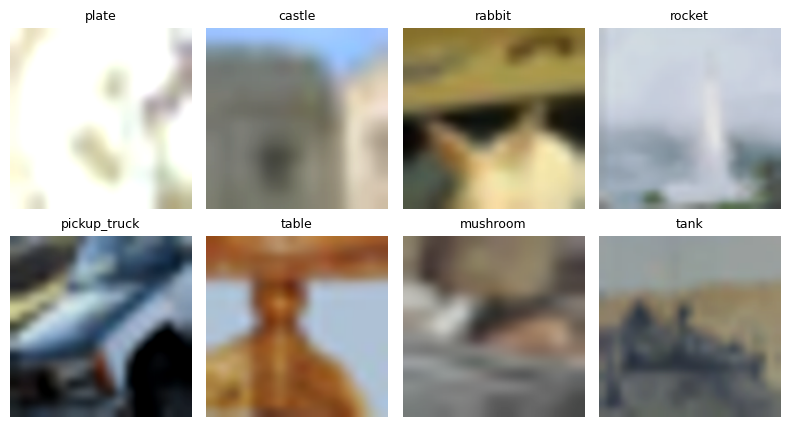

one batch: (128, 3, 224, 224) labels: (128,)


In [10]:
import matplotlib.pyplot as plt

xb, yb = next(iter(train_loader))
mean = torch.tensor(data_cfg["mean"]).view(3, 1, 1)
std = torch.tensor(data_cfg["std"]).view(3, 1, 1)
names = getattr(train_loader.dataset, "classes", None)
fig, axes = plt.subplots(2, 4, figsize=(8, 4.4))
for ax, img, lab in zip(axes.flat, xb, yb):
    ax.imshow((img * std + mean).clamp(0, 1).permute(1, 2, 0))
    ax.axis("off")
    ax.set_title(names[lab] if names else int(lab), fontsize=9)
plt.tight_layout()
plt.show()
print("one batch:", tuple(xb.shape), "labels:", tuple(yb.shape))

## 7. Training procedure

Training repeats four steps: predict, measure the error, compute gradients, update the weights.

- **Loss**: a single number measuring prediction error. Cross-entropy with *label smoothing* 0.1 puts 90% of the target mass on the
  correct class and spreads the rest over the others, which discourages over-confidence.
- **Optimizer**: the rule that updates weights from gradients. AdamW uses learning rate 1e-4 (step size) and weight decay 0.05
  (a mild pull of the weights toward zero).
- **Epoch**: one pass over the training set.
- **Learning-rate schedule**: the step size rises linearly from near zero during one *warmup* epoch, then follows a cosine curve down to zero.

Seeding and the schedule come first; the schedule is plotted for inspection.

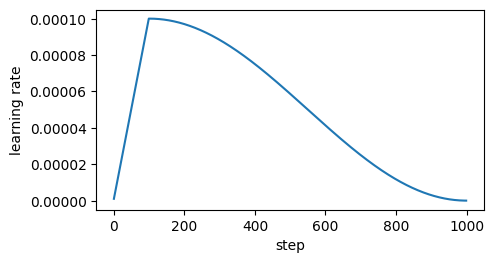

step 0: 1.00e-06 | peak: 1.00e-04 | last: 3.05e-10


In [11]:
import math
import random

import numpy as np


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def cosine_lr(step: int, total: int, warmup: int, base_lr: float) -> float:
    """Linear warmup for `warmup` steps, then cosine decay to zero at step `total`."""
    if step < warmup:
        return base_lr * (step + 1) / warmup
    progress = (step - warmup) / max(1, total - warmup)      # 0 -> 1 over the remaining steps
    return base_lr * 0.5 * (1 + math.cos(math.pi * progress))


set_seed(SEED)
curve = [cosine_lr(s, 1000, 100, LR) for s in range(1000)]
plt.figure(figsize=(5, 2.6))
plt.plot(curve)
plt.xlabel("step")
plt.ylabel("learning rate")
plt.show()
print(f"step 0: {curve[0]:.2e} | peak: {max(curve):.2e} | last: {curve[-1]:.2e}")

**Evaluation.** `model.eval()` disables training-only behaviour and `torch.no_grad()` skips gradient bookkeeping.
Accuracy is the percentage of test images whose highest-scoring class is the true class. As a reference, the untrained head
should score near chance (1% for 100 classes).

In [12]:
@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader) -> float:
    """Top-1 accuracy (%) of `model` on `loader`."""
    model.eval()
    correct = total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        with torch.autocast(device.type):
            pred = model(x).argmax(1)             # index of the highest class score
        correct += (pred == y).sum().item()
        total += y.numel()
    return 100.0 * correct / total


print(f"accuracy of the untrained head: {evaluate(model.to(device), test_loader):.2f}%")

accuracy of the untrained head: 0.85%


**One training epoch.** The `GradScaler` belongs to AMP: 16-bit gradients can underflow to zero, so the loss is multiplied by a large
factor before `backward()` and the gradients are divided by it again before the update.

In [13]:
def train_one_epoch(model, loader, opt, criterion, scaler, step, total_steps, warmup_steps, base_lr):
    """Train for one epoch; return (mean loss, updated global step)."""
    model.train()
    loss_sum = 0.0
    for x, y in loader:
        for g in opt.param_groups:                        # learning rate for this step
            g["lr"] = cosine_lr(step, total_steps, warmup_steps, base_lr)
        x, y = x.to(device), y.to(device)
        with torch.autocast(device.type):
            loss = criterion(model(x), y)                 # 1. predict, 2. measure error
        opt.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()                     # 3. compute gradients
        scaler.step(opt)                                  # 4. update weights
        scaler.update()
        loss_sum += loss.item()
        step += 1
    return loss_sum / len(loader), step

**Metrics.** Besides accuracy, three quantities describe a model:
- **Parameters**: the number of stored learned values. A shared block is counted once.
- **FLOPs**: arithmetic operations for one image (one multiply-add counts as 2). This measures *compute*.
- **Throughput**: images per second at inference. This measures *actual speed* on the given hardware.

The iterative model still executes 12 blocks per image, so its FLOPs are expected to equal the baseline's.

In [14]:
import time

from torch.utils.flop_counter import FlopCounterMode


@torch.no_grad()
def count_gflops(model: nn.Module) -> float:
    """Forward-pass GFLOPs for one 224 x 224 image."""
    model.eval()
    with FlopCounterMode(display=False) as fc:
        model(torch.randn(1, 3, 224, 224, device=device))
    return fc.get_total_flops() / 1e9


@torch.no_grad()
def measure_throughput(model: nn.Module, batch: int, iters: int, warmup: int = 2) -> float:
    """Inference throughput in images per second (GPU synchronised before timing stops)."""
    model.eval()
    x = torch.randn(batch, 3, 224, 224, device=device)
    with torch.autocast(device.type):
        for _ in range(warmup):
            model(x)
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        for _ in range(iters):
            model(x)
        torch.cuda.synchronize()
    return batch * iters / (time.perf_counter() - t0)


b, i_ = build_baseline().to(device), build_iterative(0).to(device)
print(f"GFLOPs: baseline {count_gflops(b):.2f} | iterative {count_gflops(i_):.2f} (equal: same compute)")
del b, i_

GFLOPs: baseline 2.51 | iterative 2.51 (equal: same compute)


**Experiment runner.** `run_experiment` builds a model, measures its metrics, trains it, evaluates after every epoch, and writes the
result JSON to Google Drive after each epoch. If a complete result file for `name` already exists, it is loaded instead of retraining
(an interrupted run restarts from epoch 1). The JSON fields match the server runs in `docs/results/`.

In [15]:
import json


def save_result(name: str, info: dict) -> None:
    (OUT_DIR / f"{name}.json").write_text(json.dumps(info, indent=2))


def run_experiment(name: str, builder, epochs: int = EPOCHS, lr: float = LR, wd: float = WEIGHT_DECAY,
                   warmup_epochs: float = WARMUP_EPOCHS) -> dict:
    """Fine-tune `builder()` on CIFAR-100 and return the result dictionary."""
    path = OUT_DIR / f"{name}.json"
    if path.exists():
        done = json.loads(path.read_text())
        if len(done.get("history", [])) == epochs:
            print(f"[{name}] complete result found in {OUT_DIR.name}/, skipping "
                  f"(final acc {done['final_test_acc']:.2f}%)")
            return done
    set_seed(SEED)
    model = builder().to(device)
    train_l, test_l = make_loaders(model)
    info = {"name": name, "device": str(device), "params": n_params(model), "gflops": count_gflops(model),
            "throughput_img_s": measure_throughput(model, TP_BATCH, TP_ITERS), "history": []}
    print(f"[{name}] params={info['params']:,} GFLOPs={info['gflops']:.2f} "
          f"throughput={info['throughput_img_s']:.0f} img/s")
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scaler = torch.amp.GradScaler("cuda")
    total, warm, step, t_run = epochs * len(train_l), int(warmup_epochs * len(train_l)), 0, time.time()
    for ep in range(epochs):
        t0 = time.time()
        loss, step = train_one_epoch(model, train_l, opt, criterion, scaler, step, total, warm, lr)
        acc = evaluate(model, test_l)
        info["history"].append({"epoch": ep + 1, "train_loss": loss, "test_acc": acc,
                                "epoch_time_s": time.time() - t0})
        info.update(final_test_acc=acc, best_test_acc=max(h["test_acc"] for h in info["history"]),
                    total_time_s=time.time() - t_run)
        save_result(name, info)
        print(f"[{name}] epoch {ep + 1}/{epochs} loss={loss:.4f} acc={acc:.2f} ({time.time() - t0:.0f}s)")
    print(f"[{name}] total time: {info['total_time_s']:.0f}s")
    return info

## 8. Experiments: baseline and shared blocks 0 and 6

The three models are trained sequentially with the same recipe. Each run re-seeds first so the comparison is controlled.
On a Colab T4 each run is expected to take roughly 15 to 25 minutes (an estimate, not a measurement; the A4000 lab server needed about
8 minutes). The first run also downloads CIFAR-100 (about 160 MB).

In [16]:
RUNS = {"baseline": build_baseline,
        "iterative_b0": lambda: build_iterative(0),
        "iterative_b6": lambda: build_iterative(6)}
results = {name: run_experiment(name, builder) for name, builder in RUNS.items()}
print("finished:", list(results))

[baseline] complete result found in iterative_vit/, skipping (final acc 87.11%)
[iterative_b0] complete result found in iterative_vit/, skipping (final acc 34.30%)
[iterative_b6] complete result found in iterative_vit/, skipping (final acc 30.26%)
finished: ['baseline', 'iterative_b0', 'iterative_b6']


## 9. Results

One row per model.

In [17]:
import pandas as pd


def summarize(res: dict) -> pd.DataFrame:
    """Results table with one row per run."""
    return pd.DataFrame([{"model": k, "params (M)": round(v["params"] / 1e6, 3), "GFLOPs": round(v["gflops"], 2),
                          "throughput (img/s)": round(v["throughput_img_s"]),
                          "final acc (%)": round(v["final_test_acc"], 2),
                          "best acc (%)": round(v["best_test_acc"], 2), "time (s)": round(v["total_time_s"])}
                         for k, v in res.items()])


print(summarize(results).to_string(index=False))

       model  params (M)  GFLOPs  throughput (img/s)  final acc (%)  best acc (%)  time (s)
    baseline       5.544    2.51                4759          87.11         87.11      1063
iterative_b0       0.650    2.51                4300          34.30         34.30       992
iterative_b6       0.650    2.51                4406          30.26         30.26       998


**Reference results from the lab server.** The repository is public, so the saved A4000 results (`docs/results/*.json`) are fetched
from GitHub for comparison. If the download fails, the cell continues without them.

In [18]:
import urllib.request

RAW = "https://raw.githubusercontent.com/reddy-nithin/Iterative-Transformers/main/docs/results/"
server = {}
for ours, theirs in {"baseline": "baseline", "iterative_b0": "iterative", "iterative_b6": "iterative_b6"}.items():
    try:
        with urllib.request.urlopen(f"{RAW}{theirs}.json", timeout=10) as r:
            server[ours] = json.load(r)
    except Exception as e:
        print(f"skipping server results for {ours} ({type(e).__name__})")
for k, v in server.items():
    print(f"server A4000 {k}: final acc {v['final_test_acc']:.2f}%, params {v['params']:,}")

server A4000 baseline: final acc 86.77%, params 5,543,716
server A4000 iterative_b0: final acc 34.76%, params 650,212
server A4000 iterative_b6: final acc 30.70%, params 650,212


**Accuracy per epoch.** Solid lines are this notebook; dashed lines are the A4000 server runs (when available).

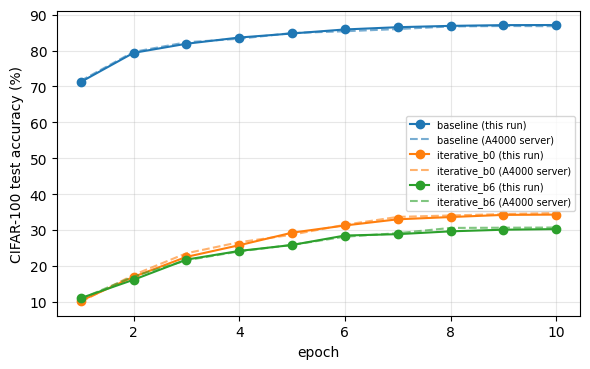

In [19]:
fig, ax = plt.subplots(figsize=(6, 3.8))
for i, (k, v) in enumerate(results.items()):
    ax.plot([h["epoch"] for h in v["history"]], [h["test_acc"] for h in v["history"]],
            marker="o", color=f"C{i}", label=f"{k} (this run)")
    if k in server:
        ax.plot([h["epoch"] for h in server[k]["history"]], [h["test_acc"] for h in server[k]["history"]],
                "--", color=f"C{i}", alpha=0.6, label=f"{k} (A4000 server)")
ax.set_xlabel("epoch")
ax.set_ylabel("CIFAR-100 test accuracy (%)")
ax.grid(alpha=0.3)
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

**Caveat on speed measurements.** Throughput depends on the hardware, so Colab and A4000 figures are not comparable with each other.
Models should be compared only within the same run. Accuracy transfers across machines up to small run-to-run noise.

## 10. Interpretation

Reference results from the A4000 server (10 epochs, seed 0):

| Model | Params | Final test acc |
|---|---|---|
| Baseline | 5.544 M | 86.77% |
| Iterative, block 0 x 12 | 0.650 M | 34.76% |
| Iterative, block 6 x 12 | 0.650 M | 30.70% |

A Colab T4 run is expected to land within about one or two points of these figures, since GPU kernels are not bit-identical across machines.

- **Size versus accuracy.** Parameters fall by 88%, but accuracy drops from about 87% to about 31 to 35%. Naively sharing one pretrained
  block does not work under this recipe.
- **No compute saving.** FLOPs are unchanged because the block still runs 12 times. Sharing reduces memory and storage, not time.
- **Choice of block.** A middle block (6) did not outperform block 0. A single seed and 10 epochs cannot establish a ranking.
- **Convergence.** Both iterative models were still improving at epoch 10, and a learning rate of 1e-4 was chosen for ordinary fine-tuning.

Further directions: all 12 block indices; a higher learning rate and longer schedule for the shared model; two or three seeds;
gentler designs such as sharing within groups of blocks or small per-iteration adapters.

## 11. Shared block applied with an explicit `for` loop

In the advisor meeting of 29 September, the proposed construction was: take the pretrained weights of one block from the state dict,
build a block with them, and pass the data through that block **12 times in a `for` loop**. Section 5 reaches the same architecture
differently, by repeating one object inside `nn.Sequential`.

| | Section 5 (`iterative_bK`) | This section (`looped_bK`) |
|---|---|---|
| Mechanism | `nn.Sequential(*[block] * 12)` | `for _ in range(12): x = block(x)` |
| Weights | one block, shared | one block, shared |
| Expected result | | numerically identical |

Because both apply the same function with the same weights, the two should give the same outputs and, up to GPU nondeterminism, the
same accuracy. The cells below verify the equivalence directly and then train both loop models to confirm it empirically.

In [20]:
from timm.models.vision_transformer import Block


class LoopedBlock(nn.Module):
    """A single transformer block applied `n_iter` times in a `for` loop (one set of weights)."""

    def __init__(self, block: nn.Module, n_iter: int):
        super().__init__()
        self.block = block
        self.n_iter = n_iter

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for _ in range(self.n_iter):
            x = self.block(x)
        return x


def build_looped(block_idx: int = 0, n_iter: int = 12) -> nn.Module:
    """ViT-Tiny whose block stack is one block, initialised from pretrained block `block_idx`, looped `n_iter` times."""
    m = build_baseline()
    src = m.blocks[block_idx]
    block = Block(dim=m.embed_dim, num_heads=src.attn.num_heads, mlp_ratio=4.0, qkv_bias=True)
    block.load_state_dict(src.state_dict())              # copy the pretrained weights of the chosen block
    m.blocks = LoopedBlock(block, n_iter)
    return m

**Verification.** For both block choices the looped model must (i) have the same parameter count as the shared model, (ii) produce
the same output on the same input, and (iii) pass gradient to every tensor of the single block. Each model is built after re-seeding
so that the randomly initialised classification head is identical.

In [21]:
for k in (0, 6):
    set_seed(SEED)
    shared_m = build_iterative(k).cpu().eval()
    set_seed(SEED)
    looped_m = build_looped(k).cpu().eval()
    probe = torch.randn(2, 3, 224, 224)
    with torch.no_grad():
        max_diff = (shared_m(probe) - looped_m(probe)).abs().max().item()
    looped_m.train()
    looped_m.zero_grad()
    looped_m(probe).sum().backward()
    grads_ok = all(p.grad is not None and p.grad.abs().sum().item() > 0 for p in looped_m.blocks.block.parameters())
    print(f"block {k}: params {n_params(looped_m):,} | max |shared - looped| = {max_diff:.2e} | gradients reach block: {grads_ok}")
    assert n_params(looped_m) == n_params(shared_m) == 650_212
    assert max_diff < 1e-4 and grads_ok
del shared_m, looped_m

block 0: params 650,212 | max |shared - looped| = 0.00e+00 | gradients reach block: True
block 6: params 650,212 | max |shared - looped| = 0.00e+00 | gradients reach block: True


**Training.** The loop models are trained with the identical recipe and seed as in Section 8.

In [22]:
LOOP_RUNS = {"looped_b0": lambda: build_looped(0),
             "looped_b6": lambda: build_looped(6)}
for name, builder in LOOP_RUNS.items():
    results[name] = run_experiment(name, builder)
print(summarize({k: results[k] for k in ("iterative_b0", "looped_b0", "iterative_b6", "looped_b6")}).to_string(index=False))

[looped_b0] complete result found in iterative_vit/, skipping (final acc 34.76%)
[looped_b6] complete result found in iterative_vit/, skipping (final acc 29.77%)
       model  params (M)  GFLOPs  throughput (img/s)  final acc (%)  best acc (%)  time (s)
iterative_b0        0.65    2.51                4300          34.30         34.30       992
   looped_b0        0.65    2.51                4393          34.76         34.76      1070
iterative_b6        0.65    2.51                4406          30.26         30.26       998
   looped_b6        0.65    2.51                4398          29.77         29.77      1072


**Accuracy per epoch.** Solid lines: `nn.Sequential` sharing (Section 5). Dashed lines: explicit `for` loop.

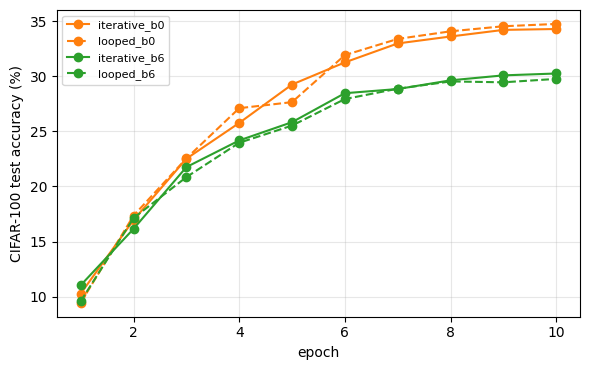

In [23]:
fig, ax = plt.subplots(figsize=(6, 3.8))
for i, k in enumerate((0, 6)):
    for style, prefix in (("-", "iterative"), ("--", "looped")):
        v = results[f"{prefix}_b{k}"]
        ax.plot([h["epoch"] for h in v["history"]], [h["test_acc"] for h in v["history"]],
                style, marker="o", color=f"C{i + 1}", label=f"{prefix}_b{k}")
ax.set_xlabel("epoch")
ax.set_ylabel("CIFAR-100 test accuracy (%)")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Observations.** The `for` loop and `nn.Sequential` constructions describe the same model: identical parameter count, matching outputs
on a common input, and gradients reaching the single shared block. Any difference in the accuracy curves above should therefore be
at the level of run-to-run GPU noise (about a point or less); a larger gap would indicate a bug rather than a property of the method.

The loop form is the more convenient one for further experiments, since the number of repetitions is a single argument
(`build_looped(block_idx, n_iter=6)` or `n_iter=18`), which allows testing how accuracy depends on the number of iterations.